
# ResNet50 Transfer Learning — Real + cGAN Combined Dataset

This notebook trains pretrained ResNet50 using your existing combined dataset:

```text
COMBINED_REAL_cGAN_VGG19/
├── train/
├── val/
└── test/
```

Hyperparameters:
- Optimizer: Adam
- Epochs: 60
- Learning rate: 0.0001
- L2 regularizer: 0.0001
- Batch size: 16
- Dropout rate: 0.50
- Frozen layers: 75


## Install Required Dependencies

In [1]:

import sys
!{sys.executable} -m pip install -q torch torchvision torchaudio scikit-learn pandas matplotlib tqdm pillow


## Imports

In [2]:

import os
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize


## Configuration

In [3]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

combined_dataset_dir = r"Philippine Medicinal Plant Leaf Dataset/COMBINED_REAL_cGAN_VGG19"

train_dir = os.path.join(combined_dataset_dir, "train")
val_dir = os.path.join(combined_dataset_dir, "val")
test_dir = os.path.join(combined_dataset_dir, "test")

batch_size = 16
epochs = 60
lr = 0.0001
l2_regularizer = 0.0001
dropout_rate = 0.50
frozen_layers = 75

results_dir = "resnet50_real_cgan_results"
os.makedirs(results_dir, exist_ok=True)

best_model_path = os.path.join(results_dir, "best_resnet50_real_cgan.pth")
checkpoint_path = os.path.join(results_dir, "latest_resnet50_real_cgan_checkpoint.pth")


Using device: cuda


## DataLoaders

In [4]:

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

num_classes = len(train_dataset.classes)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Classes:", num_classes)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))


Classes: 40
Train: 5873
Val: 969
Test: 529


## Build ResNet50 Transfer Learning Model

In [5]:

try:
    weights = models.ResNet50_Weights.IMAGENET1K_V1
    model = models.resnet50(weights=weights)
except Exception:
    model = models.resnet50(pretrained=True)

count = 0
for param in model.parameters():
    if count < frozen_layers:
        param.requires_grad = False
        count += 1
    else:
        param.requires_grad = True

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=lr,
    weight_decay=l2_regularizer
)

print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:10<00:00, 9.90MB/s]


Trainable parameters: 22013480


## Training Loop with Best Model Saving

In [6]:

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_acc = 0.0
start_epoch = 0
resume_training = False

if resume_training and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    train_accuracies = checkpoint.get("train_accuracies", [])
    val_accuracies = checkpoint.get("val_accuracies", [])
    print(f"Resuming from epoch {start_epoch}")

for epoch in range(start_epoch, epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        loop.set_postfix(train_loss=f"{loss.item():.4f}")

    avg_train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train

    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    val_acc = correct_val / total_val

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved. Val Acc: {best_val_acc:.4f}")

    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }, checkpoint_path)

print("Training finished.")
print("Best validation accuracy:", best_val_acc)


Epoch [1/60]: 100%|███████████████████████████████████████████████| 368/368 [06:40<00:00,  1.09s/it, train_loss=3.2943]


Epoch 1/60
Train Loss: 0.6923 | Train Acc: 0.8812
Val Loss:   0.0753 | Val Acc:   0.9825
Best model saved. Val Acc: 0.9825


Epoch [2/60]: 100%|███████████████████████████████████████████████| 368/368 [06:03<00:00,  1.01it/s, train_loss=4.6102]


Epoch 2/60
Train Loss: 0.0560 | Train Acc: 0.9947
Val Loss:   0.0736 | Val Acc:   0.9876
Best model saved. Val Acc: 0.9876


Epoch [3/60]: 100%|███████████████████████████████████████████████| 368/368 [06:09<00:00,  1.01s/it, train_loss=3.4364]


...

Epoch 58/60
Train Loss: 0.0139 | Train Acc: 0.9990
Val Loss:   0.0173 | Val Acc:   0.9948


Epoch [59/60]: 100%|██████████████████████████████████████████████| 368/368 [06:59<00:00,  1.14s/it, train_loss=3.7457]


Epoch 59/60
Train Loss: 0.0175 | Train Acc: 0.9985
Val Loss:   0.0580 | Val Acc:   0.9886


Epoch [60/60]: 100%|██████████████████████████████████████████████| 368/368 [06:32<00:00,  1.07s/it, train_loss=3.2448]


Epoch 60/60
Train Loss: 0.0119 | Train Acc: 0.9993
Val Loss:   0.0389 | Val Acc:   0.9876
Training finished.
Best validation accuracy: 0.9989680082559339


## Training and Validation Curves

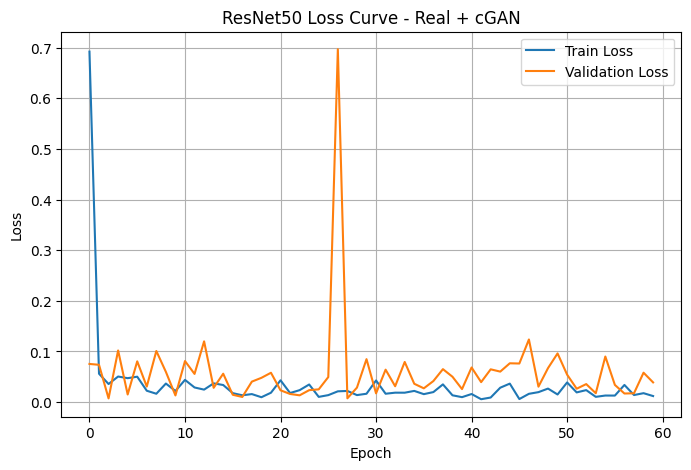

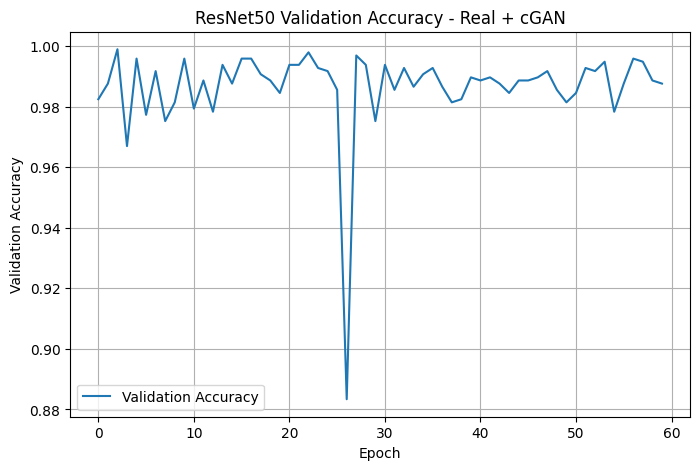

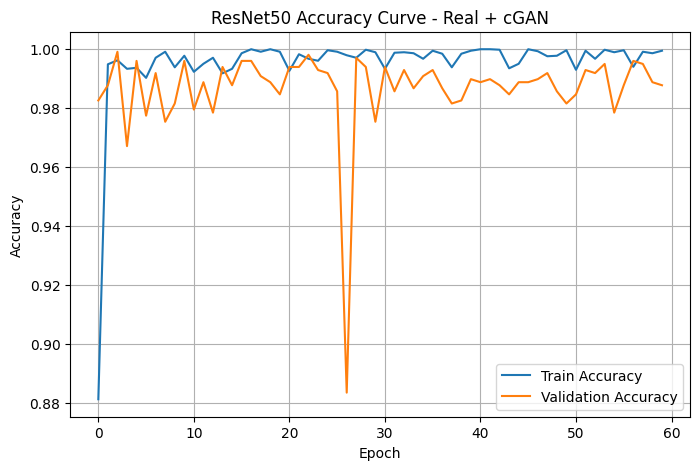

In [18]:

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss Curve - Real + cGAN")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ResNet50 Validation Accuracy - Real + cGAN")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(results_dir, "validation_accuracy_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy Curve - Real + cGAN")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300, bbox_inches="tight")
plt.show()


## Test Best Model and Compute Metrics

In [8]:

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_loss = 0.0
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        test_loss += loss.item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

avg_test_loss = test_loss / len(test_loader)

metrics_df = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-score (Macro)",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1-score (Weighted)"
    ],
    "Value": [
        avg_test_loss,
        accuracy_score(all_labels, all_preds),
        precision_score(all_labels, all_preds, average="macro", zero_division=0),
        recall_score(all_labels, all_preds, average="macro", zero_division=0),
        f1_score(all_labels, all_preds, average="macro", zero_division=0),
        precision_score(all_labels, all_preds, average="weighted", zero_division=0),
        recall_score(all_labels, all_preds, average="weighted", zero_division=0),
        f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    ]
})

metrics_path = os.path.join(results_dir, "resnet50_test_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)

print(metrics_df)


C:\Users\User\AppData\Local\Temp\ipykernel_27684\1075715709.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio

                 Metric     Value
0             Test Loss  0.082734
1              Accuracy  0.975425
2     Precision (Macro)  0.981619
3        Recall (Macro)  0.972765
4      F1-score (Macro)  0.969609
5  Precision (Weighted)  0.983621
6     Recall (Weighted)  0.975425
7   F1-score (Weighted)  0.972763


## Classification Report and Confusion Matrix

In [9]:

report = classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_path = os.path.join(results_dir, "classification_report.csv")
report_df.to_csv(report_path)
print(report_df)

cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=test_dataset.classes, columns=test_dataset.classes)
cm_path = os.path.join(results_dir, "confusion_matrix.csv")
cm_df.to_csv(cm_path)

print("Saved classification report and confusion matrix.")


                                precision    recall  f1-score     support
10Coleus scutellarioides(CS)     1.000000  1.000000  1.000000   13.000000
11Phyllanthus niruri(PN)         1.000000  1.000000  1.000000   14.000000
12Corchorus olitorius(CO)        1.000000  0.933333  0.965517   15.000000
13Momordica charantia (MC)       1.000000  1.000000  1.000000   11.000000
14Euphorbia hirta(EH)            1.000000  1.000000  1.000000   13.000000
15Curcuma longa(CL)              1.000000  0.909091  0.952381   11.000000
16Carmona retusa(CR)             1.000000  1.000000  1.000000   14.000000
17Senna alata(SA)                1.000000  1.000000  1.000000   12.000000
18Mentha cordifolia Opiz(MCO)    1.000000  0.909091  0.952381   11.000000
19Capsicum frutescens(CF)        1.000000  1.000000  1.000000   13.000000
1Hibiscus rosa-sinensis(HRS)     1.000000  1.000000  1.000000   12.000000
20Jatropha curcas(JC)            1.000000  1.000000  1.000000   15.000000
21Ocimum basilicum(OB)           1.000

## ROC-AUC Curve

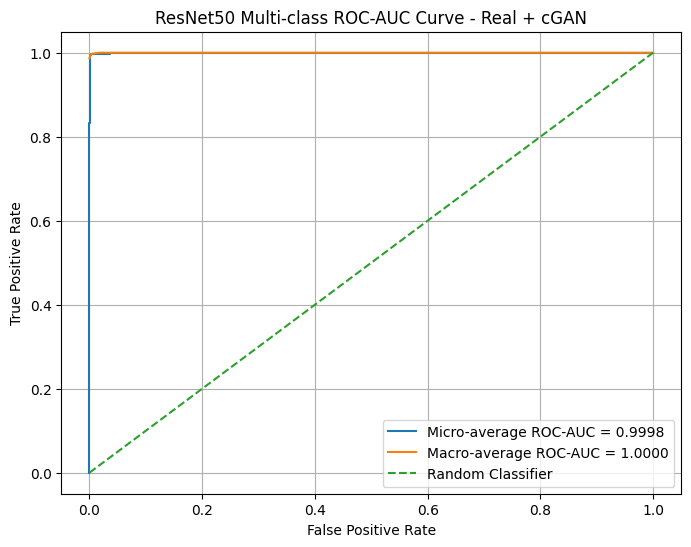

          Metric     Value
0  ROC-AUC Micro  0.999846
1  ROC-AUC Macro  0.999959


In [10]:

n_classes = len(test_dataset.classes)
y_true_bin = label_binarize(all_labels, classes=list(range(n_classes)))

fpr, tpr, roc_auc = {}, {}, {}

for class_idx in range(n_classes):
    fpr[class_idx], tpr[class_idx], _ = roc_curve(y_true_bin[:, class_idx], all_probs[:, class_idx])
    roc_auc[class_idx] = auc(fpr[class_idx], tpr[class_idx])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[class_idx] for class_idx in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for class_idx in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[class_idx], tpr[class_idx])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

roc_auc_df = pd.DataFrame({
    "Metric": ["ROC-AUC Micro", "ROC-AUC Macro"],
    "Value": [roc_auc["micro"], roc_auc["macro"]]
})
roc_auc_df.to_csv(os.path.join(results_dir, "roc_auc_scores.csv"), index=False)

plt.figure(figsize=(8, 6))
plt.plot(fpr["micro"], tpr["micro"], label=f"Micro-average ROC-AUC = {roc_auc['micro']:.4f}")
plt.plot(fpr["macro"], tpr["macro"], label=f"Macro-average ROC-AUC = {roc_auc['macro']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50 Multi-class ROC-AUC Curve - Real + cGAN")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(os.path.join(results_dir, "roc_auc_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

print(roc_auc_df)


## Zip Results

In [11]:

shutil.make_archive(results_dir, "zip", results_dir)
print("Zipped results:", results_dir + ".zip")


Zipped results: resnet50_real_cgan_results.zip
